# Grad-CAM Visualization & Predictions — NIH ChestX-Ray14

**Project:** Multi-Label Thoracic Disease Classification using Deep Learning

---

## Notebook Objectives

1. Load the best trained model and test results from `03_training.ipynb`
2. Display 20 random test predictions with color-coded correctness
3. Generate Grad-CAM++ heatmaps showing which X-ray regions influenced the model's decision
4. Display a formatted comparison table across all trained models

> **Requires:** `data_essentials.pth` from `02_preprocessing.ipynb` and `best_{ModelName}_model.pth` from `03_training.ipynb`

## 1. Imports & Device Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import torch
from torch import device, cuda, load, nn
from torchvision.models import swin_v2_b, Swin_V2_B_Weights
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from PIL import Image
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from warnings import filterwarnings

filterwarnings("ignore")

%matplotlib inline

dev = device("cuda" if cuda.is_available() else "cpu")
dev

device(type='cuda')

## 2. Load Data & Model Results

In [ ]:
checkpoint = load(r"data_essentials.pth", map_location=dev, weights_only=False)

IMG_FOLDERS    = checkpoint["img_folders"]
NUM_OF_CLASSES = checkpoint["num_of_classes"]
ALL_DISEASES   = checkpoint["all_diseases"]
test_df        = checkpoint["test_df"]

MEAN_NORM = [0.485, 0.456, 0.406]
STD_NORM  = [0.229, 0.224, 0.225]

print(f"Loaded {NUM_OF_CLASSES} classes: {ALL_DISEASES}")

Loaded 14 classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [ ]:
# Change this path to match the model you want to visualize
results = load(
    r"saved_models\best_SwinTransformer_model.pth",
    map_location=dev, weights_only=False
)

# Strip 'module.' prefix added by DataParallel during training
weights       = results['model_state']
weights_clean = {k.replace("module.", ""): v for k, v in weights.items()}

# test_preds  : binary (0/1) — used for metrics and prediction display
# test_probs  : float probabilities from sigmoid — used for Grad-CAM
# test_labels : ground truth
test_preds  = results["test_preds"]
test_probs  = results["test_probs"]
test_labels = results["test_labels"]

print(f"Test preds shape : {test_preds.shape}")
print(f"Test labels shape: {test_labels.shape}")

Test preds shape : (25596, 14)
Test labels shape: (25596, 14)


## 3. Helper Functions

In [27]:
def denormalize(tensor):
    """Reverse ImageNet normalization for display. Returns values clamped to [0, 1]."""
    mean = torch.tensor(MEAN_NORM).view(3, 1, 1)
    std  = torch.tensor(STD_NORM).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def get_disease_names(label_vector):
    """Convert binary vector to disease name string. Returns 'No Finding' if all zeros."""
    diseases = [ALL_DISEASES[i] for i, v in enumerate(label_vector) if v == 1]
    return ", ".join(diseases) if diseases else "No Finding"


def get_title_color(true_vec, pred_vec):
    """Return green for perfect match, orange for partial, red for completely wrong."""
    true_set = set(np.where(true_vec == 1)[0])
    pred_set = set(np.where(pred_vec == 1)[0])
    if true_set == pred_set:
        return "green"
    elif len(true_set & pred_set) > 0:
        return "orange"
    else:
        return "red"

## 4. Load Test Images

We load 500 test images for visualization. Transform matches training (256×256 for Swin).
Change size to 224 for ResNet/VGG/ViT, or 299 for Inception.

In [28]:
class ChestXRayDataset(Dataset):
    """Minimal dataset for visualization — loads images only, no labels."""

    def __init__(self, df, img_folders, transform=None):
        self.df          = df.reset_index(drop=True)
        self.img_folders = img_folders
        self.transform   = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "Image Index"]
        for folder in self.img_folders:
            path = os.path.join(folder, img_name)
            if os.path.exists(path):
                img = Image.open(path).convert("RGB")
                break
        if self.transform:
            img = self.transform(img)
        return img


test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_NORM, std=STD_NORM),
])

viz_dataset = ChestXRayDataset(
    test_df.iloc[:500].reset_index(drop=True),
    IMG_FOLDERS,
    transform=test_transform
)

all_imgs = [viz_dataset[i] for i in range(len(viz_dataset))]
print(f"Loaded {len(all_imgs)} images for visualization")

Loaded 500 images for visualization


## 5. Test Predictions — 20 Random Samples

🟢 Green = perfect | 🟠 Orange = partial match | 🔴 Red = completely wrong

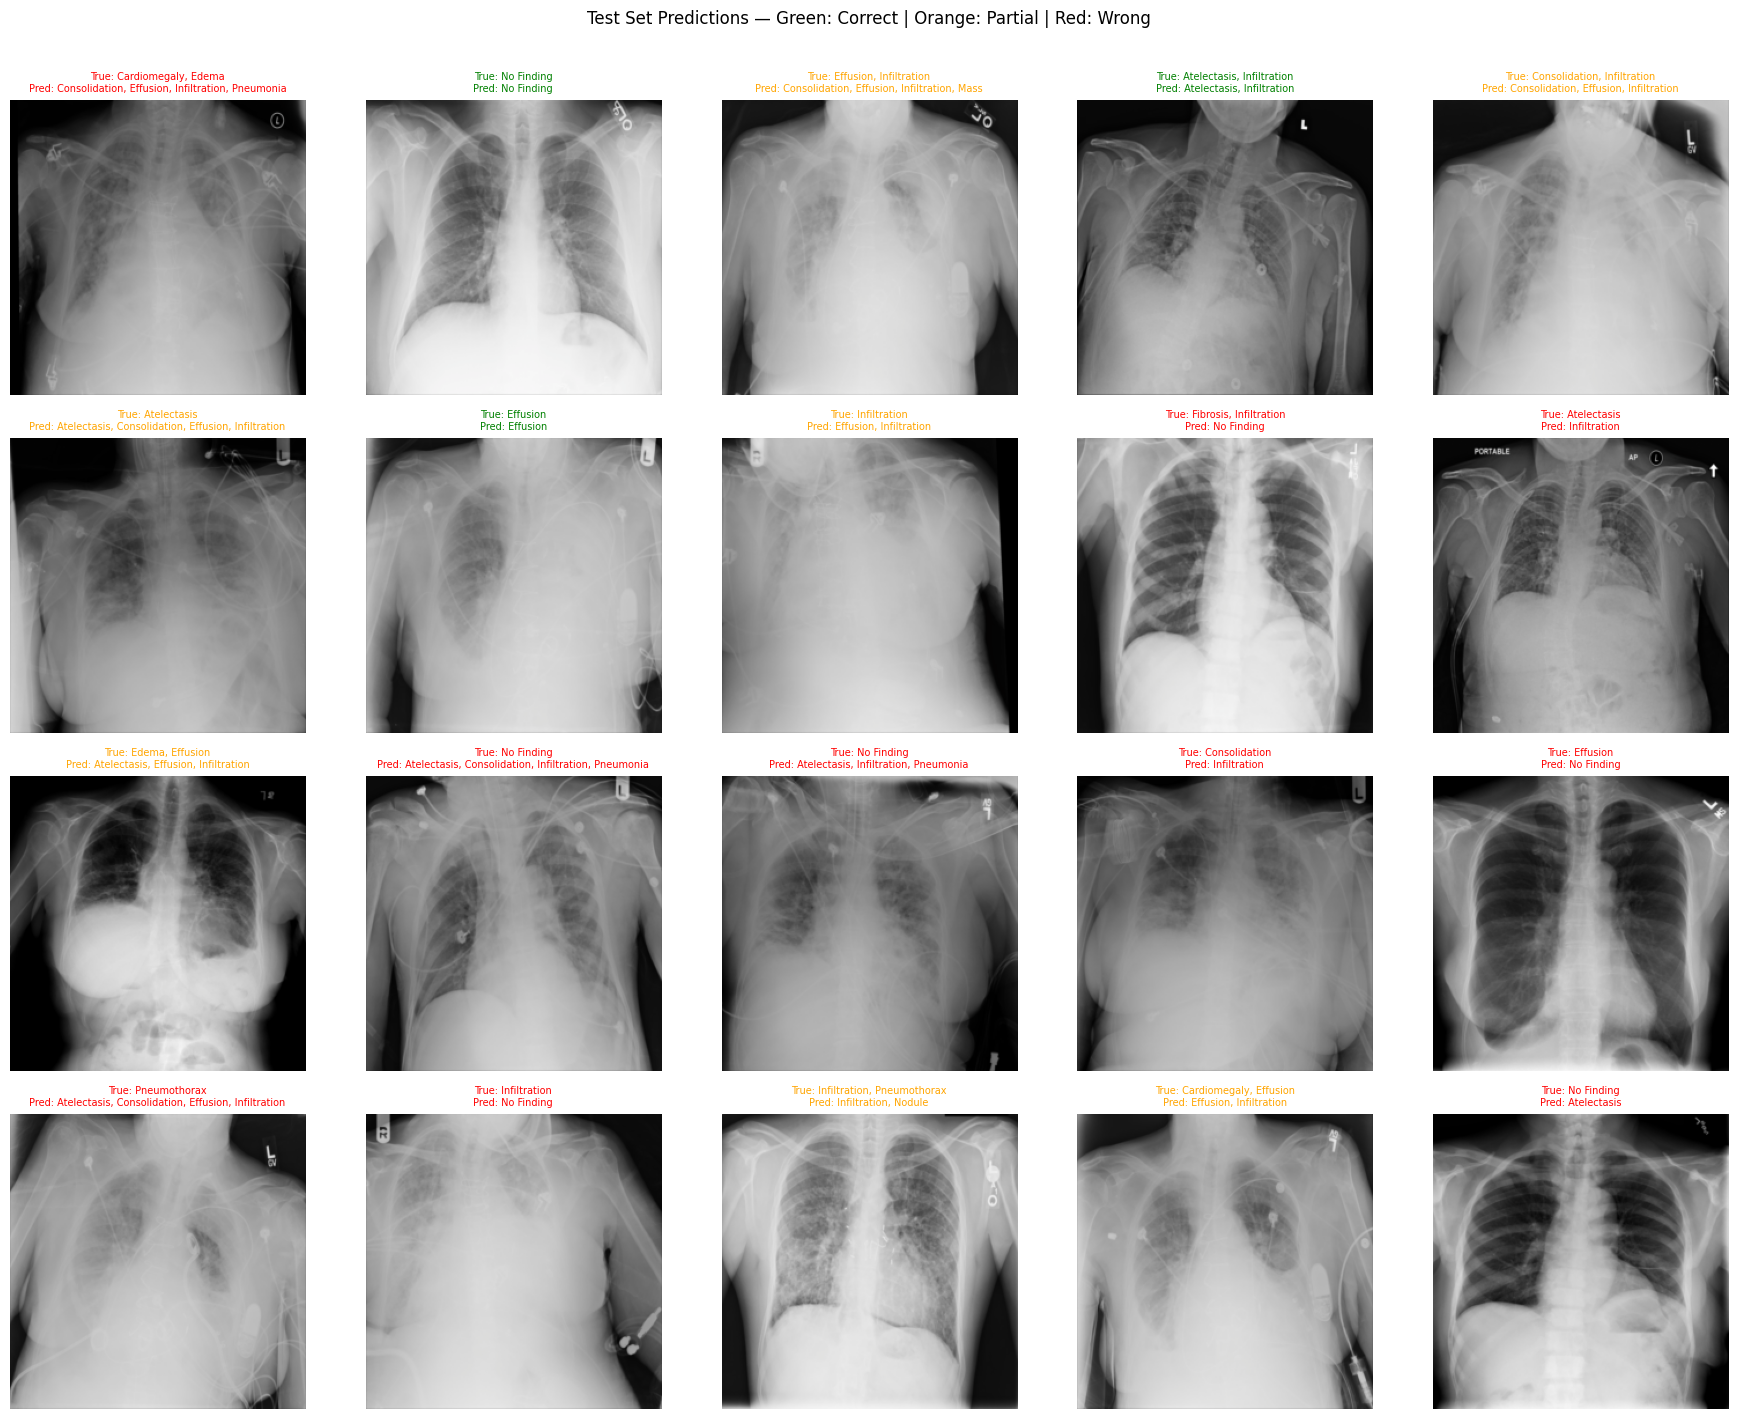

In [44]:
_, ax = plt.subplots(4, 5, figsize=(18, 14))
ax = ax.flatten()

max_idx = min(len(all_imgs), len(test_labels))
indices = np.random.choice(max_idx, size=20, replace=False)

for plot_i, idx in enumerate(indices):
    img        = denormalize(all_imgs[idx]).permute(1, 2, 0).numpy()
    true_label = get_disease_names(test_labels[idx])
    pred_label = get_disease_names(test_preds[idx])
    color      = get_title_color(test_labels[idx], test_preds[idx])

    ax[plot_i].imshow(img, cmap="gray")
    ax[plot_i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=7)
    ax[plot_i].axis("off")

plt.suptitle("Test Set Predictions — Green: Correct | Orange: Partial | Red: Wrong",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Grad-CAM++ Heatmaps

Grad-CAM++ highlights the X-ray regions that most influenced the model's prediction.
Red/warm areas = high attention from the model.

**Why GradCAM++ over standard GradCAM?**  
GradCAM++ uses higher-order gradients which gives more precise localization,
especially useful for multi-label cases where multiple diseases appear in one image.

**Why a custom MultiLabelTarget?**  
Standard Grad-CAM targets a single class. Here we sum scores of all predicted
positive diseases to produce a combined heatmap covering all relevant regions.

**reshape_transform for Swin:**  
Swin outputs features as `(batch, H*W, channels)`. The reshape converts this
to `(batch, channels, H, W)` as expected by Grad-CAM.

In [30]:
def build_model(model_fn, model_weights):
    """Build model with the same classifier structure used during training."""
    model = model_fn(model_weights.DEFAULT)
    model.head = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(model.head.in_features, NUM_OF_CLASSES)
    )
    return model.to(dev).eval()


model = build_model(swin_v2_b, Swin_V2_B_Weights)
model.load_state_dict(weights_clean)
model.eval()
print("Model loaded successfully")

Model loaded successfully


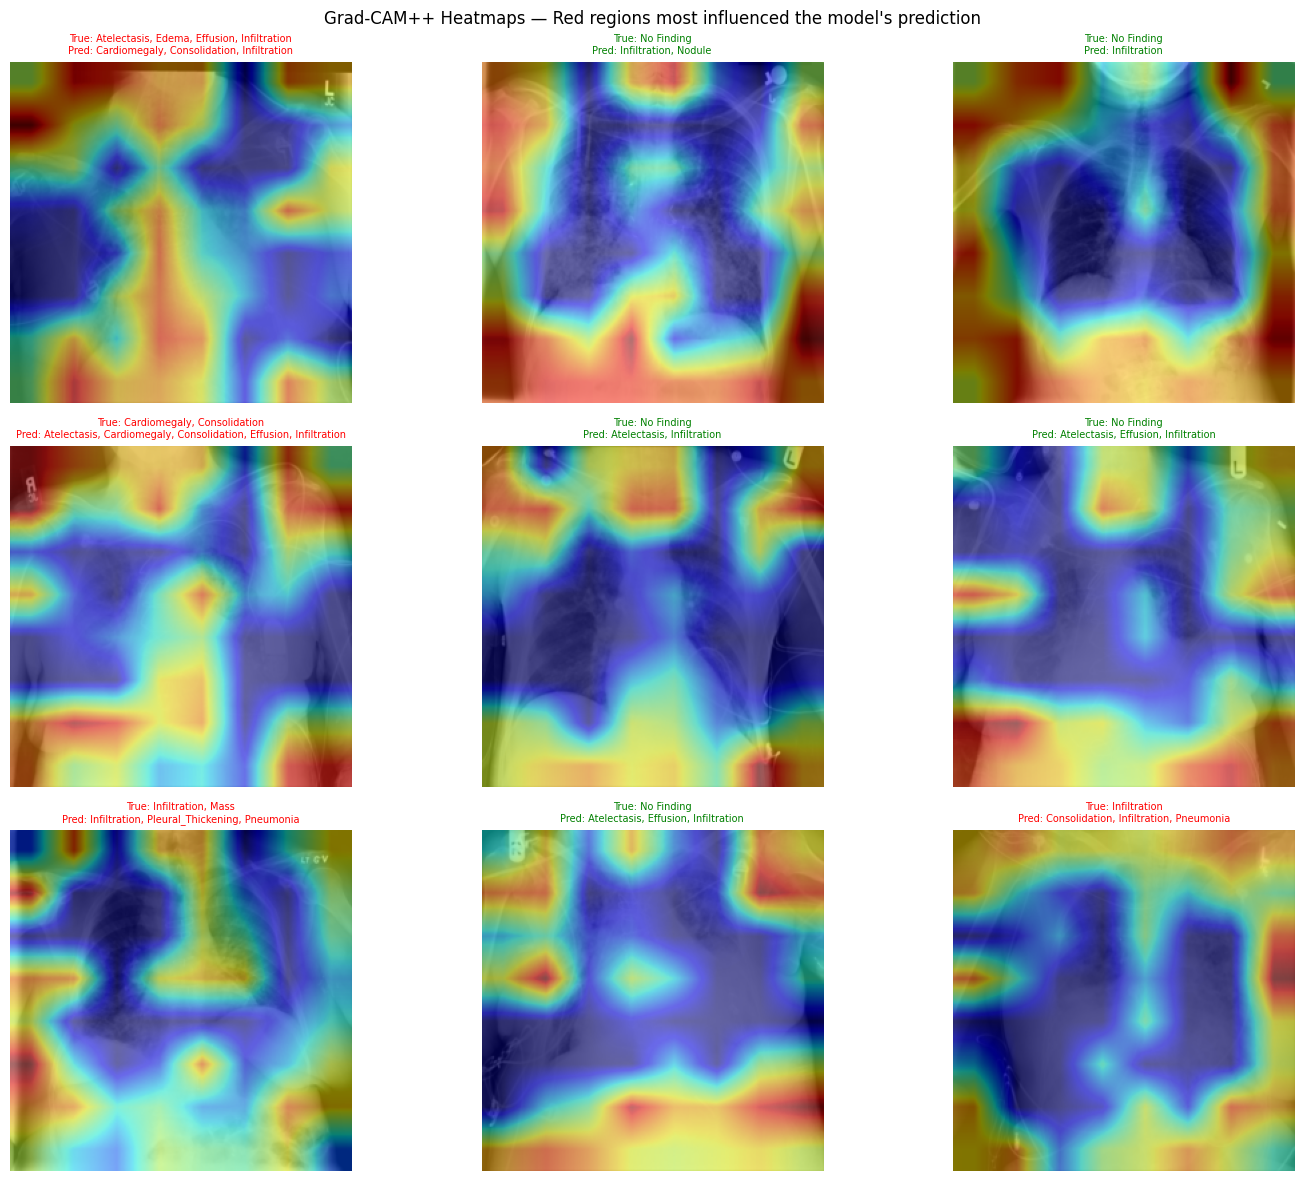

In [46]:

class MultiLabelTarget:
    """Sums scores of all predicted positive diseases for a combined Grad-CAM heatmap."""

    def __init__(self, pred_vector):
        self.pred_vector = torch.tensor(pred_vector, dtype=torch.float32)

    def __call__(self, model_output):
        return (model_output * self.pred_vector.to(model_output.device)).sum()



def show_gradcam_per_class(model, img_tensor, disease_idx, disease_name, ax):
    """Grad-CAM++ heatmap for a SINGLE disease class."""
    
    
    target_layers = [model.features[-1][-1]]
    
    cam = GradCAMPlusPlus(
        model=model,
        target_layers=target_layers,
        reshape_transform=lambda x: x.permute(0, 3, 1, 2)
    )
    
    
    
    class_target = [ClassifierOutputTarget(disease_idx)]
    
    input_tensor = img_tensor.unsqueeze(0).to(dev)
    grayscale_cam = cam(input_tensor=input_tensor, targets=class_target)
    
    
    img_np = denormalize(img_tensor).permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    
    
    
    heatmap_colored = cm.jet(grayscale_cam[0])[:, :, :3]
    alpha = 0.5
    overlay = img_np * (1 - alpha) + heatmap_colored * alpha
    overlay = np.clip(overlay, 0, 1)
    
    ax.imshow(overlay)
    ax.set_title(f"{disease_name}", fontsize=9, fontweight='bold')
    ax.axis("off")


# Original | Heatmap | Overlay
def show_gradcam_comparison(model, img_tensor, pred_vector, true_label, pred_label, ax_triple):
    """Show Original, Heatmap-only, and Overlay side-by-side."""
    
   
    target_layers = [model.features[-1][-1]]
    
    cam = GradCAMPlusPlus(
        model=model,
        target_layers=target_layers,
        reshape_transform=lambda x: x.permute(0, 3, 1, 2)
    )
    
    input_tensor = img_tensor.unsqueeze(0).to(dev)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[MultiLabelTarget(pred_vector)])
    
   
    img_np = denormalize(img_tensor).permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    heatmap = grayscale_cam[0]
    
    # 1. Original
    ax_triple[0].imshow(img_np)
    ax_triple[0].set_title("Original X-ray", fontsize=9, fontweight='bold')
    ax_triple[0].axis("off")
    
    # 2. Heatmap 
    ax_triple[1].imshow(heatmap, cmap='jet')
    ax_triple[1].set_title("Grad-CAM++ Heatmap", fontsize=9, fontweight='bold')
    ax_triple[1].axis("off")
    
    # 3. Overlay
    from matplotlib import cm
    heatmap_colored = cm.jet(heatmap)[:, :, :3]
    overlay = img_np * 0.5 + heatmap_colored * 0.5
    ax_triple[2].imshow(np.clip(overlay, 0, 1))
    
    color = get_title_color(
        np.array([1 if d in true_label else 0 for d in ALL_DISEASES]),
        pred_vector
    )
    ax_triple[2].set_title(f"Overlay\nTrue: {true_label}\nPred: {pred_label}", 
                          color=color, fontsize=8)
    ax_triple[2].axis("off")



def show_gradcam(model, img_tensor, pred_vector, true_label, pred_label, ax):
    """Generate and display a Grad-CAM++ heatmap overlay for a single image."""

  
    target_layers = [model.features[-1][-1]]

    cam = GradCAMPlusPlus(
        model=model,
        target_layers=target_layers,
        reshape_transform=lambda x: x.permute(0, 3, 1, 2)
    )

    input_tensor = img_tensor.unsqueeze(0).to(dev)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[MultiLabelTarget(pred_vector)])

    
    img_np = denormalize(img_tensor).permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    
    from matplotlib import cm
    heatmap_colored = cm.jet(grayscale_cam[0])[:, :, :3]
    alpha = 0.5
    visualization = img_np * (1 - alpha) + heatmap_colored * alpha
    visualization = np.clip(visualization, 0, 1)

    color = get_title_color(
        np.array([1 if d in true_label else 0 for d in ALL_DISEASES]),
        pred_vector
    )

    ax.imshow(visualization)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=7)
    ax.axis("off")


# Select images that have at least one predicted disease (more informative heatmaps)
has_pred = [i for i in range(min(len(all_imgs), len(test_preds)))
            if test_preds[i].sum() > 0]

selected = np.random.choice(has_pred, size=min(9, len(has_pred)), replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for plot_i, idx in enumerate(selected):
    show_gradcam(
        model       = model,
        img_tensor  = all_imgs[idx],
        pred_vector = test_probs[idx],
        true_label  = get_disease_names(test_labels[idx]),
        pred_label  = get_disease_names(test_preds[idx]),
        ax          = axes[plot_i]
    )

plt.suptitle("Grad-CAM++ Heatmaps — Red regions most influenced the model's prediction",
             fontsize=12)
plt.tight_layout()
plt.show()

## 7. Model Comparison Table

Loads the results CSV saved during training and displays a formatted comparison
across all five models. Best values highlighted in green.

In [48]:
results_path = r'C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\My Reserch Papers\chest-xray-multilabel-classification\results\All_Models_Results.csv'

results_df = pd.read_csv(results_path)

# Sort by AUC descending — Swin (proposed) should rank first
results_df = results_df.sort_values('Best AUC', ascending=False).reset_index(drop=True)
# results_df.drop('Unnamed: 8',inplace=True,axis=1)
# Highlight best AUC, F1, Recall in green and fastest training in yellow
styled = results_df.style \
    .highlight_max(subset=['Best AUC','Best Loss', 'F1','Precision', 'Recall'], color='lightgreen') \
    .highlight_min(subset=['Training_Time (Hours)'], color='lightyellow') \
    .format({
        'Best AUC': '{:.4f}', 'F1': '{:.4f}',
        'Precision': '{:.4f}', 'Recall': '{:.4f}',
        'Training_Time (Hours)': '{:.2f}'
    })

display(styled)

,Model,Best AUC,Best Loss,F1,Precision,Recall,Best Num Of Epochs,Training_Time (Hours)
0,SwinTransformer,0.8505,0.035800,0.3107,0.2876,0.3668,12-20,5.83
1,VGG19,0.8341,0.036500,0.3045,0.2751,0.3664,7,3.45
2,VisionTransformer,0.8312,0.037000,0.2931,0.2915,0.3479,7,2.57
3,Inception V3,0.8216,0.037300,0.2280,0.2100,0.2999,7,2.85
4,DenseNet,0.8163,0.037300,0.2816,0.2526,0.3289,7-15,3.67
5,ResNet,0.8134,0.038000,0.2748,0.2440,0.3326,7,3.74


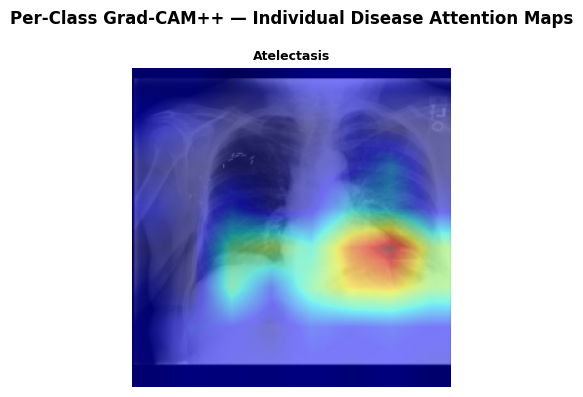

In [49]:
## 6b. Per-Class Grad-CAM++ (Individual Disease Visualization)

sample_idx = has_pred[0] 
img = all_imgs[sample_idx]


pred_diseases = [i for i, v in enumerate(test_preds[sample_idx]) if v == 1]

if len(pred_diseases) > 0:
    n = len(pred_diseases)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n > 1 else [axes]
    
    for i, disease_idx in enumerate(pred_diseases):
        show_gradcam_per_class(
            model=model,
            img_tensor=img,
            disease_idx=disease_idx,
            disease_name=ALL_DISEASES[disease_idx],
            ax=axes[i]
        )
    
   
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f"Per-Class Grad-CAM++ — Individual Disease Attention Maps",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig("per_class_gradcam.png", dpi=300, bbox_inches='tight')
    plt.show()

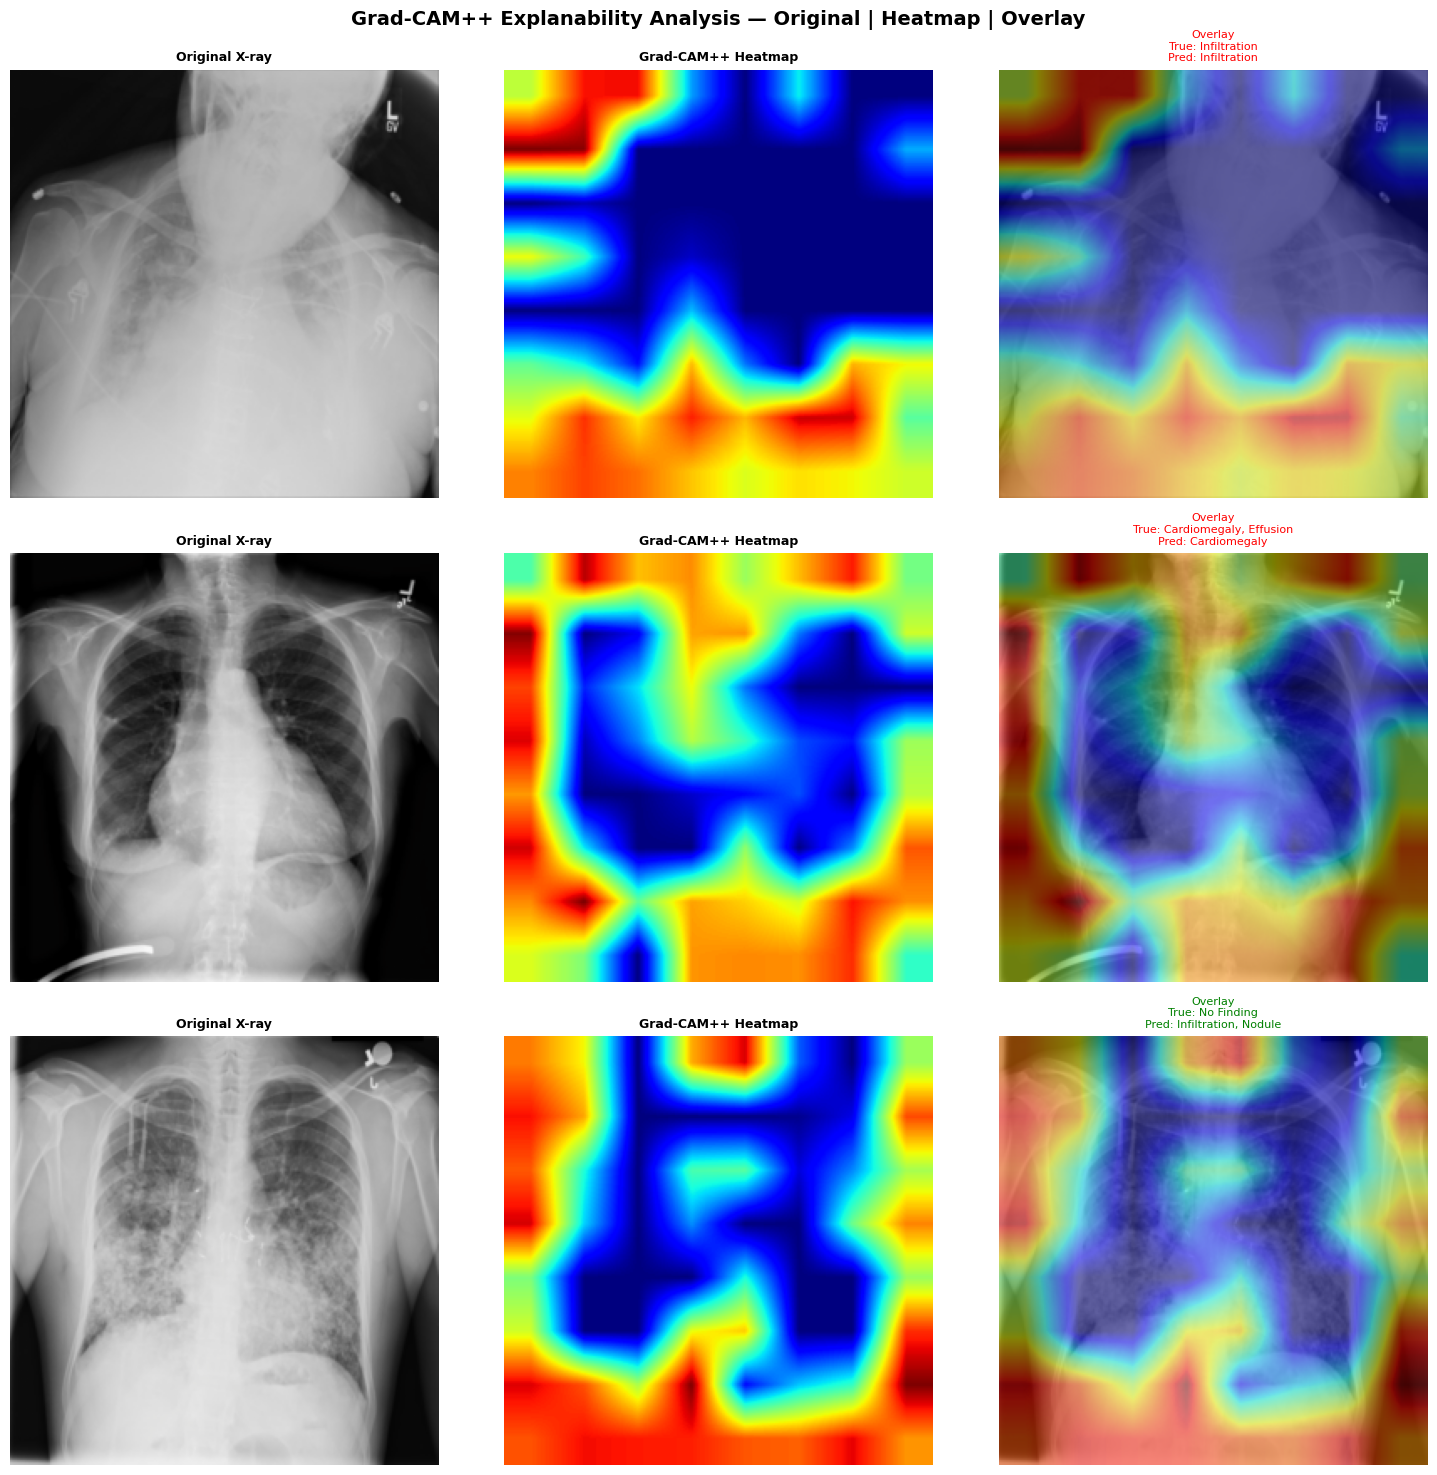

In [50]:
## 6c. Grad-CAM++ Comparison Figure — Paper Quality


correct_idx = [i for i in has_pred 
               if get_title_color(test_labels[i], test_preds[i]) == "green"]
partial_idx = [i for i in has_pred 
               if get_title_color(test_labels[i], test_preds[i]) == "orange"]
wrong_idx = [i for i in has_pred 
             if get_title_color(test_labels[i], test_preds[i]) == "red"]

selected_examples = []
if correct_idx: selected_examples.append(np.random.choice(correct_idx))
if partial_idx: selected_examples.append(np.random.choice(partial_idx))
if wrong_idx: selected_examples.append(np.random.choice(wrong_idx))

fig, axes = plt.subplots(len(selected_examples), 3, figsize=(15, 5*len(selected_examples)))
if len(selected_examples) == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(selected_examples):
    show_gradcam_comparison(
        model=model,
        img_tensor=all_imgs[idx],
        pred_vector=test_probs[idx],
        true_label=get_disease_names(test_labels[idx]),
        pred_label=get_disease_names(test_preds[idx]),
        ax_triple=axes[row]
    )

plt.suptitle("Grad-CAM++ Explanability Analysis — Original | Heatmap | Overlay",
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("gradcam_comparison_paper.png", dpi=300, bbox_inches='tight')
plt.show()

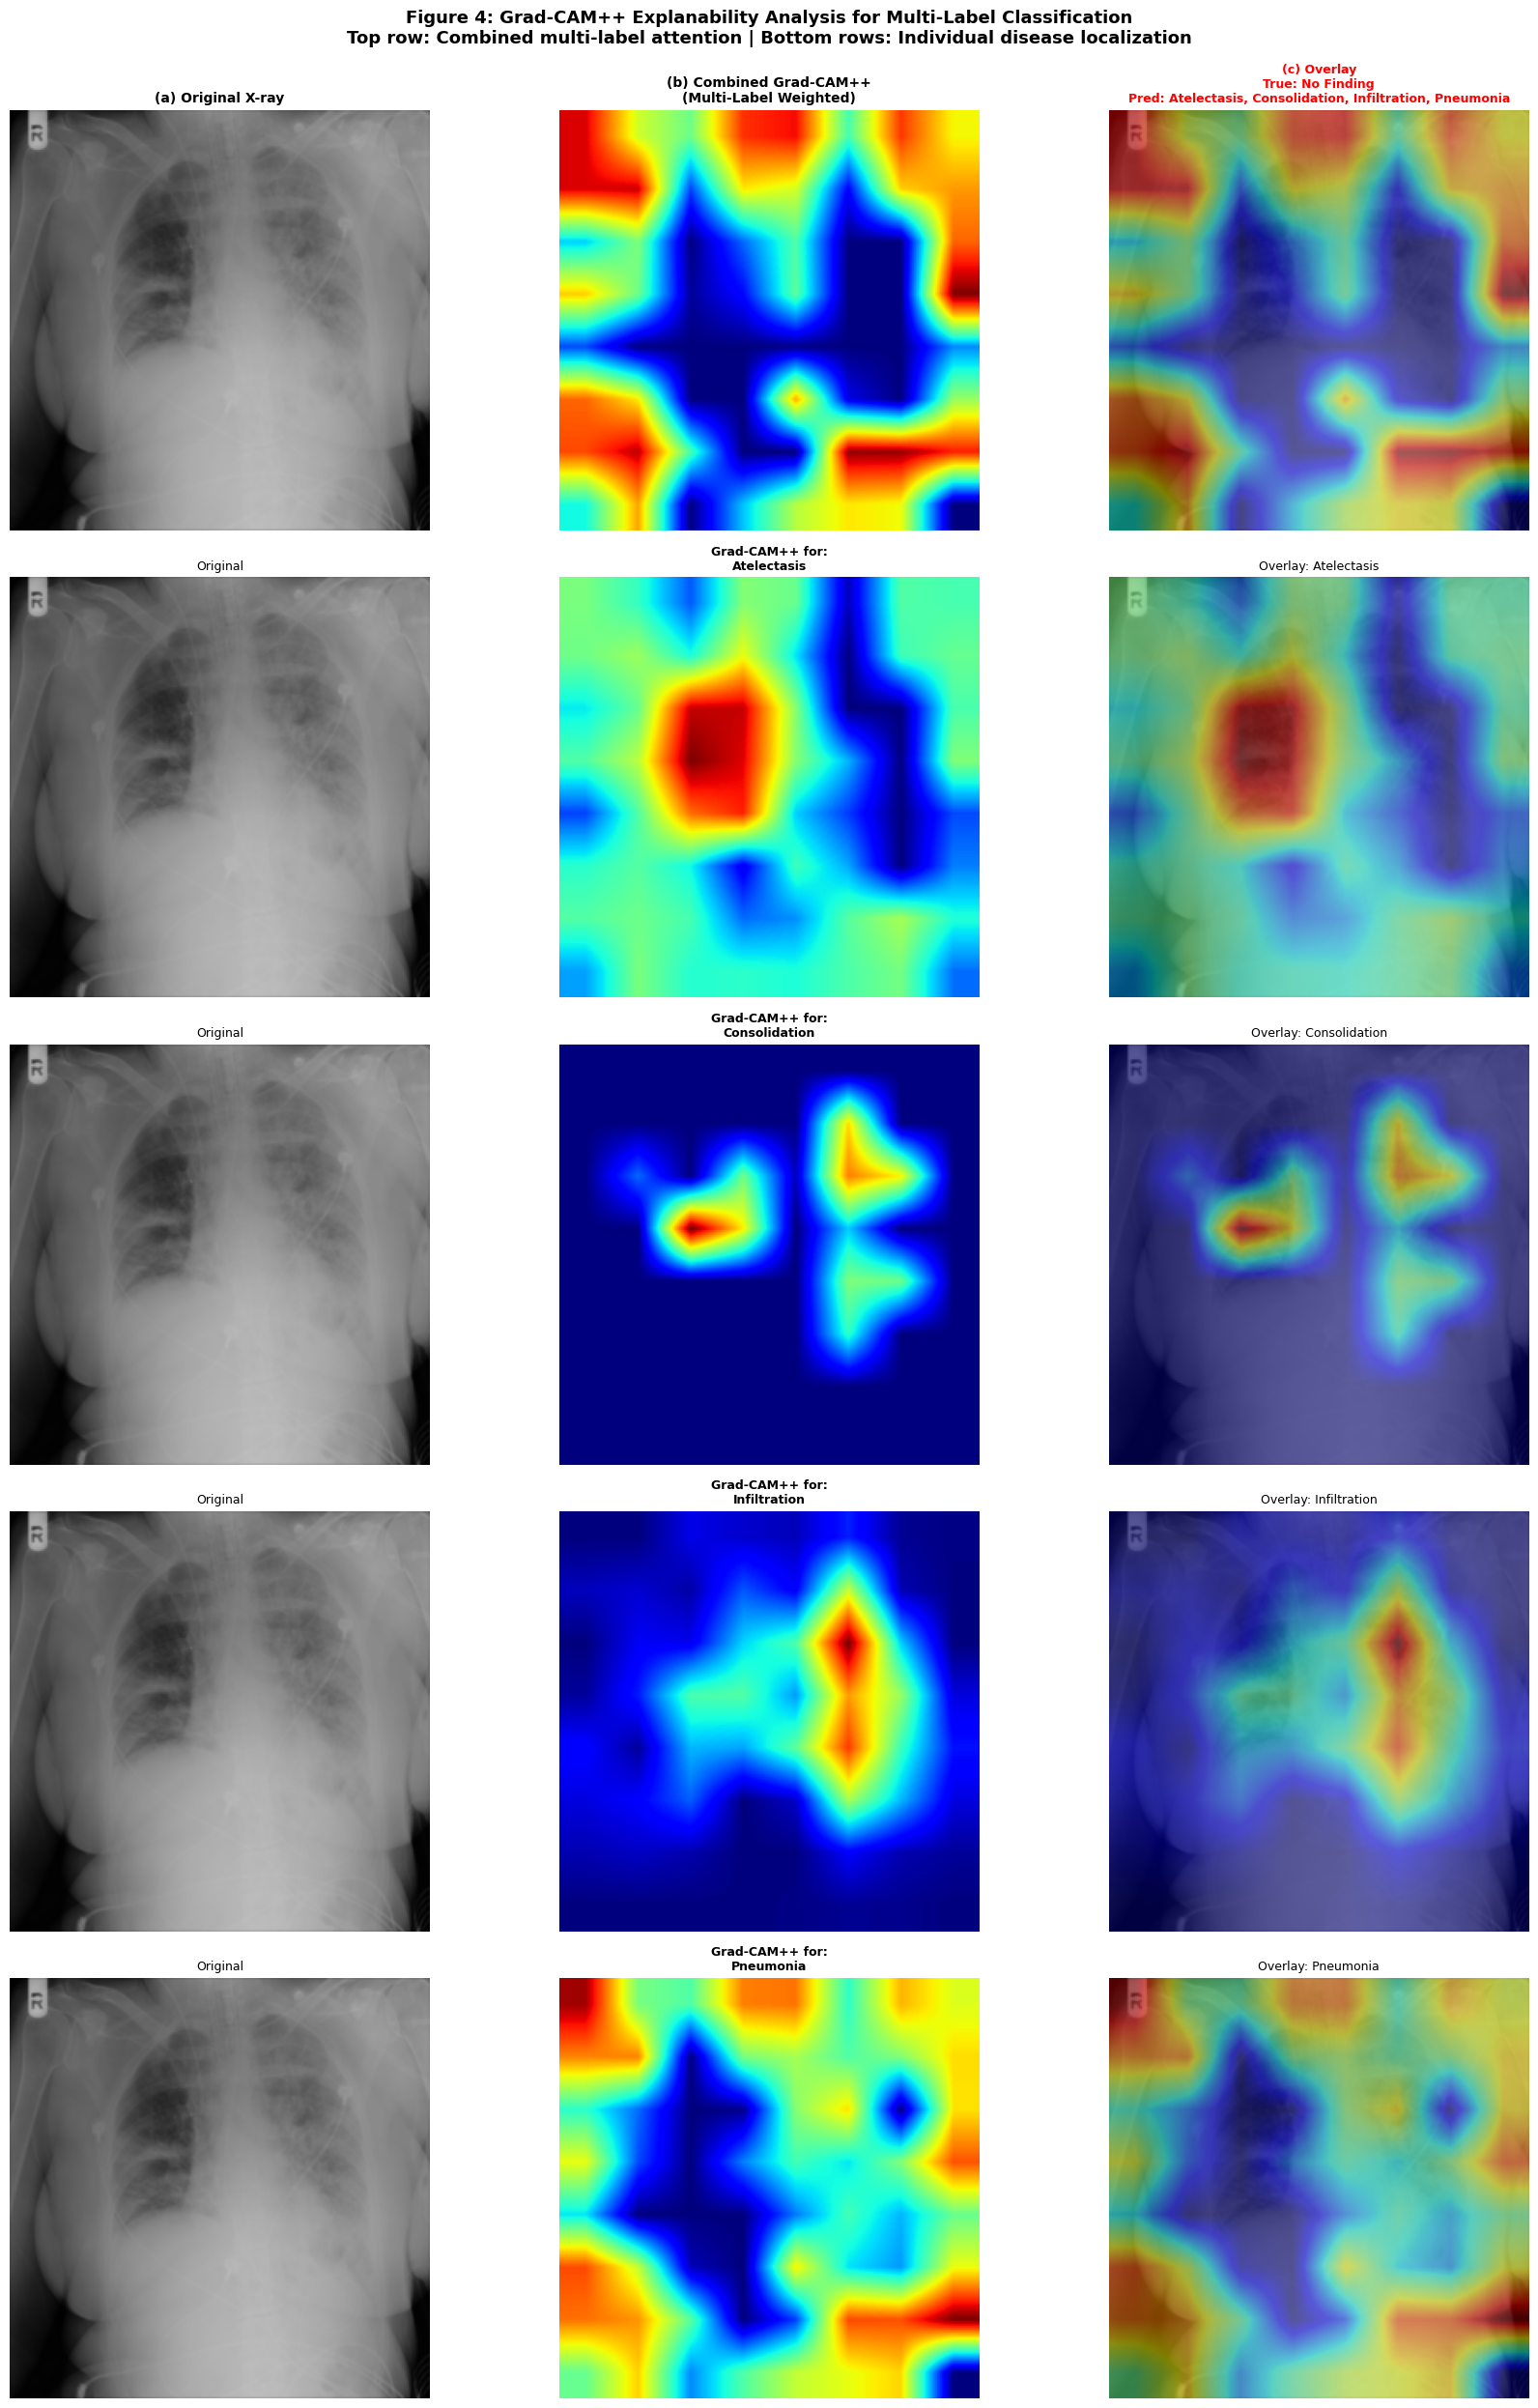

In [51]:
## 6d. Figure 4: Comprehensive Grad-CAM++ Explanability (Paper Figure)

# (multiple diseases)
complex_idx = [i for i in has_pred if test_preds[i].sum() >= 2]
if complex_idx:
    idx = np.random.choice(complex_idx)
else:
    idx = has_pred[0]

img = all_imgs[idx]
true_label = get_disease_names(test_labels[idx])
pred_label = get_disease_names(test_preds[idx])

pred_diseases = [i for i, v in enumerate(test_preds[idx]) if v == 1]
n_diseases = len(pred_diseases)

# Figure:combined،per-class
total_rows = 1 + n_diseases
fig = plt.figure(figsize=(18, 5*total_rows))

# === Combined Multi-Label CAM ===
ax1 = plt.subplot(total_rows, 3, 1)
ax2 = plt.subplot(total_rows, 3, 2)
ax3 = plt.subplot(total_rows, 3, 3)

# Original
img_np = denormalize(img).permute(1, 2, 0).cpu().numpy()
img_np = np.clip(img_np, 0, 1)
ax1.imshow(img_np)
ax1.set_title("(a) Original X-ray", fontsize=10, fontweight='bold')
ax1.axis('off')

# Combined Heatmap
target_layers = [model.features[-1][-1]]
cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers,
    reshape_transform=lambda x: x.permute(0, 3, 1, 2)
)
input_tensor = img.unsqueeze(0).to(dev)
grayscale_cam = cam(input_tensor=input_tensor, targets=[MultiLabelTarget(test_probs[idx])])

ax2.imshow(grayscale_cam[0], cmap='jet')
ax2.set_title("(b) Combined Grad-CAM++\n(Multi-Label Weighted)", fontsize=10, fontweight='bold')
ax2.axis('off')

# Combined Overlay

heatmap_colored = cm.jet(grayscale_cam[0])[:, :, :3]
overlay = img_np * 0.5 + heatmap_colored * 0.5
color = get_title_color(test_labels[idx], test_preds[idx])
ax3.imshow(np.clip(overlay, 0, 1))
ax3.set_title(f"(c) Overlay\nTrue: {true_label}\nPred: {pred_label}", 
              color=color, fontsize=9, fontweight='bold')
ax3.axis('off')

# === Per-Class CAMs ===
for row, disease_idx in enumerate(pred_diseases, start=2):
    base = (row - 1) * 3 + 1
    
    # Original
    ax_orig = plt.subplot(total_rows, 3, base)
    ax_orig.imshow(img_np)
    ax_orig.set_title(f"Original", fontsize=9)
    ax_orig.axis('off')
    
    # Per-Class Heatmap
    ax_heat = plt.subplot(total_rows, 3, base + 1)
    
    class_target = [ClassifierOutputTarget(disease_idx)]
    class_cam = cam(input_tensor=input_tensor, targets=class_target)
    
    ax_heat.imshow(class_cam[0], cmap='jet')
    ax_heat.set_title(f"Grad-CAM++ for:\n{ALL_DISEASES[disease_idx]}", 
                      fontsize=9, fontweight='bold')
    ax_heat.axis('off')
    
    # Per-Class Overlay
    ax_over = plt.subplot(total_rows, 3, base + 2)
    heatmap_colored = cm.jet(class_cam[0])[:, :, :3]
    overlay = img_np * 0.5 + heatmap_colored * 0.5
    ax_over.imshow(np.clip(overlay, 0, 1))
    ax_over.set_title(f"Overlay: {ALL_DISEASES[disease_idx]}", fontsize=9)
    ax_over.axis('off')

plt.suptitle("Figure 4: Grad-CAM++ Explanability Analysis for Multi-Label Classification\n"
             "Top row: Combined multi-label attention | Bottom rows: Individual disease localization",
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("figure4_gradcam_comprehensive.png", dpi=300, bbox_inches='tight')
plt.show()